In [2]:
import torch
import torch.nn as nn
import tiktoken


## Layer normalization

It normalizes the inputs across the features for each data point, ensuring that the mean is close to 0 and the variance is close to 1 for each data point. This helps to mitigate issues like vanishing or exploding gradients, allowing for faster convergence during training.

In [ ]:
torch.manual_seed(42)
# contains 2 sequences, each of length 5
batch_example = torch.randn(2, 5)
# nn layer that takes input of size 5 and outputs size 6, followed by ReLU activation
layer = nn.Sequential(nn.Linear(5, 6), nn.ReLU())
output = layer(batch_example)
print(output)

tensor([[0.0000, 0.1842, 0.0052, 0.7233, 0.0000, 0.5298],
        [0.0000, 0.0000, 0.0000, 0.2237, 0.0000, 0.7727]],
       grad_fn=<ReluBackward0>)


In [31]:
# compute mean and variance across the column dimension to get one mean and variance per row
mean = output.mean(dim=-1, keepdim=True)
var = output.var(dim=-1, keepdim=True)
print("Mean:", mean)
print("Variance:", var)

Mean: tensor([[0.2404],
        [0.1661]], grad_fn=<MeanBackward1>)
Variance: tensor([[0.0982],
        [0.0963]], grad_fn=<VarBackward0>)


In [ ]:
out_norm = (output - mean) / torch.sqrt(var)
print("Normalized output:", out_norm)

mean = out_norm.mean(dim=-1, keepdim=True)
var = out_norm.var(dim=-1, keepdim=True)
print("Mean:", mean)
print("Variance:", var)

Normalized output: tensor([[-0.7672, -0.1794, -0.7506,  1.5410, -0.7672,  0.9234],
        [-0.5351, -0.5351, -0.5351,  0.1857, -0.5351,  1.9546]],
       grad_fn=<DivBackward0>)
Mean: tensor([[0.0000e+00],
        [1.4901e-08]], grad_fn=<MeanBackward1>)
Variance: tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [34]:
torch.set_printoptions(sci_mode=False)
print("Mean:", mean)
print("Variance:", var)

Mean: tensor([[0.0000],
        [0.0000]], grad_fn=<MeanBackward1>)
Variance: tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [ ]:
class LayerNorm(nn.Module):
    def __init__(self, embedding_dim: int, eps: float = 1e-5):
        super().__init__()
        self.eps = eps  # prevent division by zero
        self.scale = nn.Parameter(torch.ones(embedding_dim))
        self.shift = nn.Parameter(torch.zeros(embedding_dim))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        normalized_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * normalized_x + self.shift

In [37]:
ln = LayerNorm(5)
out_ln = ln(batch_example)
mean = out_ln.mean(dim=-1, keepdim=True)
var = out_ln.var(dim=-1, keepdim=True, unbiased=False)
print("Mean:", mean)
print("Variance:", var)

Mean: tensor([[-0.0000],
        [ 0.0000]], grad_fn=<MeanBackward1>)
Variance: tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


## GELU activation function
GELU (Gaussian Error Linear Unit) is an activation function that combines properties of both ReLU and sigmoid functions. It is defined as:
$$\text{GELU}(x) = x \cdot \Phi(x) \approx 0.5 \cdot x \cdot \left(1 + \tanh\left(\sqrt{\frac{2}{\pi}} \left(x + 0.044715 \cdot x^3\right)\right)\right)$$
Where $\Phi(x)$ is the cumulative distribution function of the standard normal distribution, and the approximation is used for computational efficiency.

In [ ]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return (
            x * 0.5 * (1.0 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) * (x + 0.044715 * torch.pow(x, 3))
            ))
        )

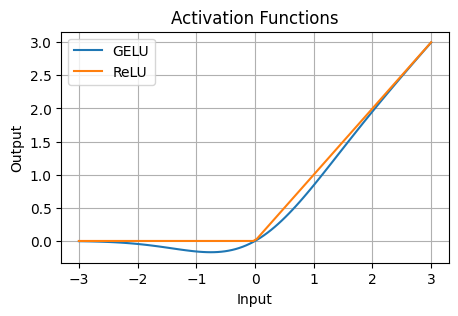

In [58]:
import matplotlib.pyplot as plt

x = torch.linspace(-3, 3, 100)
gelu = GELU()
relu = nn.ReLU()
plt.figure(figsize=(5, 3))

plt.plot(x, gelu(x), label="GELU")
plt.plot(x, relu(x), label="ReLU")
plt.title("Activation Functions")
plt.xlabel("Input")
plt.ylabel("Output")
plt.legend()
plt.grid()
plt.show()

## FeedForward layer

The FeedForward layer in the Transformer architecture consists of two linear transformations with an activation function (like GELU) in between.

The first linear transformation expands the dimensionality (e.g., from 768 to 3072), and the second linear transformation reduces it back to the original dimensionality (e.g., from 3072 to 768).

In [60]:
class FeedForward(nn.Module):
    def __init__(self, embedding_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embedding_dim, 4 * embedding_dim),
            GELU(),
            nn.Linear(4 * embedding_dim, embedding_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

In [ ]:
ff = FeedForward(768)
# simulate a batch of 2 sequences, each of length 3, and each token represented by a 768-dimensional embedding
x = torch.randn(2, 3, 768)
output = ff(x)
print(output.shape)

torch.Size([2, 3, 768])


## Adding shortcut connections

Adding shortcut connections can help mitigate the vanishing gradient problem and improve training. A shortcut connection allows inputs to be added directly to the output of a layer, which can help gradients flow more easily through the network during backpropagation.

In [ ]:
class ExampleDNN(nn.Module):
    def __init__(self, layer_sizes: list[int], use_shortcut: bool = False):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.net = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[i], layer_sizes[i + 1]), GELU())
            for i in range(len(layer_sizes) - 1)
        ])

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        for layer in self.net:
            layer_out = layer(x)
            if self.use_shortcut and x.shape == layer_out.shape:
                x = x + layer_out
            else:
                x = layer_out
        return x


In [ ]:
layer_sizes = [3] * 5 + [1]
sample_input = torch.tensor([[1., 0., -1.]])
torch.manual_seed(42)
model = ExampleDNN(layer_sizes, use_shortcut=False)

In [93]:
def print_gradients(model: nn.Module, x: torch.Tensor):
    output = model(x)
    target = torch.tensor([[0.0]])

    loss = nn.MSELoss()(output, target)
    loss.backward()

    for name, param in model.named_parameters():
        if "weight" in name:
            print(f"{name} gradient mean: {param.grad.abs().mean().item():.4f}")


print_gradients(model, sample_input)

net.0.0.weight gradient mean: 0.0001
net.1.0.weight gradient mean: 0.0002
net.2.0.weight gradient mean: 0.0003
net.3.0.weight gradient mean: 0.0022
net.4.0.weight gradient mean: 0.0068


In [94]:
torch.manual_seed(42)
model_shortcut = ExampleDNN(layer_sizes, use_shortcut=True)
print_gradients(model_shortcut, sample_input)

net.0.0.weight gradient mean: 0.0024
net.1.0.weight gradient mean: 0.0042
net.2.0.weight gradient mean: 0.0033
net.3.0.weight gradient mean: 0.0035
net.4.0.weight gradient mean: 0.0112


## Implementing GPT model

In [ ]:
from dataclasses import dataclass, asdict

@dataclass
class GPTConfig:
    # GPT-2 small config
    vocab_size: int = 50257
    context_length: int = 1024
    embedding_dim: int = 768
    num_heads: int = 8
    num_layers: int = 12
    dropout: float = 0.1
    qkv_bias: bool = False

    def to_dict(self):
        return asdict(self)


In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, embedding_dim, num_heads, context_length, dropout=0.0, qkv_bias=False):
        super().__init__()
        assert embedding_dim % num_heads == 0, "embedding_dim must be divisible by num_heads"
        self.embedding_dim = embedding_dim
        self.num_heads = num_heads
        self.head_dim = embedding_dim // num_heads

        # combine q, k, v projections into a single linear layer for efficiency
        self.qkv = nn.Linear(embedding_dim, embedding_dim * 3, bias=qkv_bias)
        self.out_proj = nn.Linear(embedding_dim, embedding_dim)
        self.dropout = nn.Dropout(p=dropout)
        self.register_buffer(
            "mask", torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        batch_size, seq_len, _ = x.shape

        # compute q, k, v in one go and then split them
        qkv = self.qkv(x)  # (batch_size, seq_len, embedding_dim * 3)
        qkv = qkv.view(batch_size, seq_len, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)  # (3, batch_size, num_heads, seq_len, head_dim)
        query, keys, values = qkv[0], qkv[1], qkv[2]

        attention_scores = query @ keys.transpose(-2, -1)
        # trim the mask to the current sequence length and apply it to attention scores
        attention_scores.masked_fill_(self.mask.bool()[:seq_len, :seq_len], -torch.inf)

        attention_weights = torch.softmax(attention_scores / (self.head_dim**0.5), dim=-1)
        attention_weights = self.dropout(attention_weights)

        context_vectors = attention_weights @ values
        # reshape back to (batch_size, seq_len, num_heads, head_dim)
        context_vectors = context_vectors.transpose(1, 2).contiguous()
        context_vectors = context_vectors.view(batch_size, seq_len, self.embedding_dim)
        output = self.out_proj(context_vectors)
        return output

In [106]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg: GPTConfig):
        super().__init__()
        self.attention = MultiHeadAttention(
            embedding_dim=cfg.embedding_dim,
            num_heads=cfg.num_heads,
            context_length=cfg.context_length,
            dropout=cfg.dropout,
            qkv_bias=cfg.qkv_bias,
        )
        self.ff = FeedForward(cfg.embedding_dim)
        self.ln1 = LayerNorm(cfg.embedding_dim)
        self.ln2 = LayerNorm(cfg.embedding_dim)
        self.dropout = nn.Dropout(p=cfg.dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # apply attention and feedforward with residual connections and layer normalization
        x = x + self.dropout(self.attention(self.ln1(x)))
        x = x + self.dropout(self.ff(self.ln2(x)))
        return x


In [107]:
torch.manual_seed(42)
x = torch.randn(2, 4, 768)  # batch of 2 sequences, each of length 4, embedding dim 768
cfg = GPTConfig()
block = TransformerBlock(cfg)
output = block(x)
print(output.shape)

torch.Size([2, 4, 768])


In [ ]:
class GPTModel(nn.Module):
    def __init__(self, cfg: GPTConfig):
        super().__init__()
        self.token_embedding = nn.Embedding(cfg.vocab_size, cfg.embedding_dim)
        self.pos_embedding = nn.Embedding(cfg.context_length, cfg.embedding_dim)
        self.dropout = nn.Dropout(cfg.dropout)

        self.transformer_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg.num_layers)]
        )
        self.final_layer_norm = LayerNorm(cfg.embedding_dim)
        self.out_head = nn.Linear(cfg.embedding_dim, cfg.vocab_size, bias=False)

    def forward(self, input_ids: torch.Tensor) -> torch.Tensor:
        batch_size, seq_len = input_ids.size()
        token_embeddings = self.token_embedding(input_ids)
        pos_ids = torch.arange(seq_len, device=input_ids.device)
        pos_embeddings = self.pos_embedding(pos_ids)
        x = self.dropout(token_embeddings + pos_embeddings)

        x = self.transformer_blocks(x)
        x = self.final_layer_norm(x)
        # project to vocabulary size to get logits for each token position
        logits = self.out_head(x)
        return logits

In [97]:
tokenizer = tiktoken.get_encoding("gpt2")
batch = ["Every effort moves you", "Every day holds a"]
tokenized_batch = [torch.tensor(tokenizer.encode(txt)) for txt in batch]
tokenized_batch = torch.stack(tokenized_batch, dim=0)
print(tokenized_batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


In [109]:
torch.manual_seed(42)
model = GPTModel(GPTConfig())
out = model(tokenized_batch)
print(out.shape)

torch.Size([2, 4, 50257])


In [110]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Total parameters: 163,009,536


In [ ]:
# GPT-2 uses weight tying, so the output head shares weights with the token embedding layer
print(model.token_embedding.weight.shape)
print(model.out_head.weight.shape)

torch.Size([50257, 768])
torch.Size([50257, 768])


In [114]:
total_params_gpt2 = total_params - model.out_head.weight.numel()
print(f"Total parameters considering weight tying: {total_params_gpt2:,}")

Total parameters considering weight tying: 124,412,160


In [118]:
ff_params = sum(p.numel() for p in model.transformer_blocks[0].ff.parameters())
print(f"Feed-forward parameters: {ff_params:,}")
attention_params = sum(p.numel() for p in model.transformer_blocks[0].attention.parameters())
print(f"Attention parameters: {attention_params:,}")

Feed-forward parameters: 4,722,432
Attention parameters: 2,360,064


In [120]:
total_size_bytes = sum(p.numel() * p.element_size() for p in model.parameters())
total_size_mb = total_size_bytes / (1024 ** 2)
print(f"Total model size: {total_size_mb:,.2f} MB")

Total model size: 621.83 MB


In [ ]:
def generate_text(
    model: GPTModel, input_ids: torch.Tensor, max_length: int, context_length: int
) -> torch.Tensor:
    model.eval()  # disable dropout and other training-specific layers
    for _ in range(max_length):
        # ensure the input to the model does not exceed the context length
        input_ids_cutted = input_ids[:, -context_length:]
        with torch.no_grad():
            logits = model(input_ids_cutted)

        # get the logits for the last token position and sample the next token
        next_token_logits = logits[:, -1, :]  # (batch_size, vocab_size)
        # use greedy decoding to select the token with the highest probability
        next_token_prob = torch.softmax(next_token_logits, dim=-1)
        next_token_id = torch.argmax(next_token_prob, dim=-1, keepdim=True)
        input_ids = torch.cat((input_ids, next_token_id), dim=1)

    return input_ids

In [135]:
start_text = "Once upon a time"
input_ids = torch.tensor(tokenizer.encode(start_text)).unsqueeze(0)  # add batch dimension
print(f"input_ids.shape: {input_ids.shape}")

generated_ids = generate_text(model, input_ids, max_length=5, context_length=cfg.context_length)
print(f"generated_ids length: {len(generated_ids[0])}")
generated_text = tokenizer.decode(generated_ids[0].tolist())
print(generated_text)

input_ids.shape: torch.Size([1, 4])
generated_ids length: 9
Once upon a timeWr introduce Suns whworn
